In [180]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

df = pd.read_csv("data_3_1_1.csv")
df.head()

,x1,x2,class
0,6.70,6.79,1
1,6.92,3.87,1
2,7.87,5.36,1
3,2.93,6.91,0
4,6.67,4.92,1


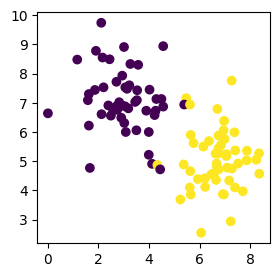

In [181]:
plt.figure(figsize = (3, 3))
plt.scatter(df["x1"], df["x2"], c = df["class"])
plt.show()

In [182]:
# Split X, y and scale X

data = df.to_numpy()
X = data[:, :-1]
y = data[:, -1]


X = (X - np.mean(X, axis = 0)) / np.std(X, axis = 0)
X[:5]

array([[ 0.89427341,  0.50441425],
       [ 1.00118579, -1.50690571],
       [ 1.46285286, -0.48058148],
       [-0.93781591,  0.58707123],
       [ 0.87969445, -0.78365709]])

In [183]:

tX = torch.tensor(X, dtype = torch.float32)
ty = torch.tensor(y, dtype = torch.float32)

In [184]:
# Define model
def model(X, W1, b1, W2, b2, W3, b3):
  # layer 1
  Z1 = torch.matmul(X, W1) + b1
  A1 = torch.sigmoid(Z1)

  # layer 2
  Z2 = torch.matmul(A1, W2) + b2
  A2 = torch.sigmoid(Z2)

  # layer 3
  Z3 = torch.matmul(A2, W3) + b3
  A3 = torch.sigmoid(Z3)
  return A3

In [185]:
W1 = torch.randn(2, 5, requires_grad = True)
b1 = torch.randn(1, 5, requires_grad = True)
W2 = torch.randn(5, 5, requires_grad = True)
b2 = torch.randn(1, 5, requires_grad = True)
W3 = torch.randn(5, 1, requires_grad = True)
b3 = torch.randn(1, 1, requires_grad = True)

cost_func = nn.BCELoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3], lr = 0.1)

for epoch in range(1, 1001):
  h = model(tX, W1, b1, W2, b2, W3, b3)
  cost = cost_func(h, ty.reshape(-1, 1))
  cost.backward()
  optimizer.step()
  optimizer.zero_grad()

  print(f"Epoch: {epoch:03d}, Cost: {cost.item():.4f}")

Epoch: 001, Cost: 0.7805
Epoch: 002, Cost: 0.7637
Epoch: 003, Cost: 0.7488
Epoch: 004, Cost: 0.7356
Epoch: 005, Cost: 0.7238
Epoch: 006, Cost: 0.7133
Epoch: 007, Cost: 0.7040
Epoch: 008, Cost: 0.6958
Epoch: 009, Cost: 0.6885
Epoch: 010, Cost: 0.6820
Epoch: 011, Cost: 0.6762
Epoch: 012, Cost: 0.6710
Epoch: 013, Cost: 0.6663
Epoch: 014, Cost: 0.6621
Epoch: 015, Cost: 0.6584
Epoch: 016, Cost: 0.6549
Epoch: 017, Cost: 0.6518
Epoch: 018, Cost: 0.6490
Epoch: 019, Cost: 0.6464
Epoch: 020, Cost: 0.6439
Epoch: 021, Cost: 0.6417
Epoch: 022, Cost: 0.6396
Epoch: 023, Cost: 0.6376
Epoch: 024, Cost: 0.6357
Epoch: 025, Cost: 0.6339
Epoch: 026, Cost: 0.6322
Epoch: 027, Cost: 0.6306
Epoch: 028, Cost: 0.6290
Epoch: 029, Cost: 0.6275
Epoch: 030, Cost: 0.6260
Epoch: 031, Cost: 0.6246
Epoch: 032, Cost: 0.6231
Epoch: 033, Cost: 0.6217
Epoch: 034, Cost: 0.6204
Epoch: 035, Cost: 0.6190
Epoch: 036, Cost: 0.6177
Epoch: 037, Cost: 0.6163
Epoch: 038, Cost: 0.6150
Epoch: 039, Cost: 0.6137
Epoch: 040, Cost: 0.6124


In [186]:
# Evaluate the model using accuracy

h = model(tX, W1, b1, W2, b2, W3, b3)
y_pred = (h>=0.5).float()
acc = (y_pred == ty.reshape(-1, 1)).float().mean()
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 97.00%


# Dataset 2.0

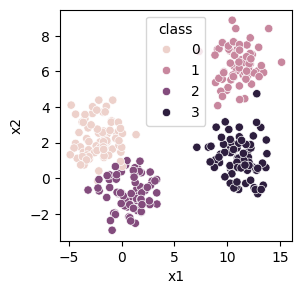

In [187]:
df2 = pd.read_csv("data_3_2.csv")

plt.figure(figsize = (3, 3))
sns.scatterplot(data = df2, x = "x1", y = "x2", hue = "class")
plt.show()  

In [188]:
# Split X, y, scale X, covert array to tensor

data2 = df2.to_numpy()
X2 = data2[:, :-1]
y2 = data2[:, -1]

X2 = (X2 - np.mean(X2, axis = 0)) / np.std(X2, axis = 0)

tX2 = torch.tensor(X2, dtype = torch.float32)
ty2 = torch.tensor(y2, dtype = torch.long)

In [189]:
# Define model2
def model2(X, W1, b1, W2, b2, W3, b3):
  # layer 1
  Z1 = torch.matmul(X, W1) + b1
  A1 = torch.sigmoid(Z1)

  # layer 2
  Z2 = torch.matmul(A1, W2) + b2
  A2 = torch.sigmoid(Z2)

  # layer 3
  Z3 = torch.matmul(A2, W3) + b3

  return Z3

In [190]:
W1 = torch.randn(2, 5, requires_grad = True)
b1 = torch.randn(1, 5, requires_grad = True)
W2 = torch.randn(5, 5, requires_grad = True)
b2 = torch.randn(1, 5, requires_grad = True)
W3 = torch.randn(5, 4, requires_grad = True)
b3 = torch.randn(1, 4, requires_grad = True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3], lr = 0.1)

for epoch in range(1, 1001):
  Z = model2(tX2, W1, b1, W2, b2, W3, b3)
  cost = cost_func(Z, ty2)
  cost.backward()
  optimizer.step()
  optimizer.zero_grad()

  print(f"Epoch: {epoch:03d}, Cost: {cost.item():.4f}")

Epoch: 001, Cost: 2.2024
Epoch: 002, Cost: 2.1376
Epoch: 003, Cost: 2.0775
Epoch: 004, Cost: 2.0214
Epoch: 005, Cost: 1.9690
Epoch: 006, Cost: 1.9199
Epoch: 007, Cost: 1.8738
Epoch: 008, Cost: 1.8305
Epoch: 009, Cost: 1.7896
Epoch: 010, Cost: 1.7512
Epoch: 011, Cost: 1.7149
Epoch: 012, Cost: 1.6808
Epoch: 013, Cost: 1.6486
Epoch: 014, Cost: 1.6184
Epoch: 015, Cost: 1.5899
Epoch: 016, Cost: 1.5633
Epoch: 017, Cost: 1.5383
Epoch: 018, Cost: 1.5149
Epoch: 019, Cost: 1.4931
Epoch: 020, Cost: 1.4727
Epoch: 021, Cost: 1.4538
Epoch: 022, Cost: 1.4361
Epoch: 023, Cost: 1.4197
Epoch: 024, Cost: 1.4045
Epoch: 025, Cost: 1.3904
Epoch: 026, Cost: 1.3773
Epoch: 027, Cost: 1.3652
Epoch: 028, Cost: 1.3540
Epoch: 029, Cost: 1.3437
Epoch: 030, Cost: 1.3341
Epoch: 031, Cost: 1.3252
Epoch: 032, Cost: 1.3170
Epoch: 033, Cost: 1.3094
Epoch: 034, Cost: 1.3023
Epoch: 035, Cost: 1.2958
Epoch: 036, Cost: 1.2897
Epoch: 037, Cost: 1.2840
Epoch: 038, Cost: 1.2787
Epoch: 039, Cost: 1.2737
Epoch: 040, Cost: 1.2691


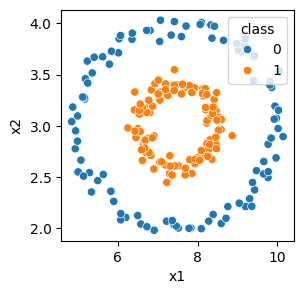

In [191]:
# load data and visualize
df3 = pd.read_csv("data_3_1_2.csv")

plt.figure(figsize = (3, 3))
sns.scatterplot(data = df3, x = "x1", y = "x2", hue = "class")
plt.show()

In [192]:
# Split X, y, training set, test set, Scaling
from sklearn.model_selection import train_test_split
data3 = df3.to_numpy()
X = data3[:, :-1]
y = data3[:, -1]

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4,
                                                    random_state=168)

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

(200, 2)
(200,)


In [193]:
# Convert array to tensor
tX_train = torch.tensor(X_train, dtype = torch.float32)
ty_train = torch.tensor(y_train, dtype = torch.float32)
tX_test = torch.tensor(X_test, dtype = torch.float32)
ty_test = torch.tensor(y_test, dtype = torch.float32)

In [194]:
# Define logistic model
def logistic_model(X, W, b):
  Z = torch.matmul(X, W) + b
  A = torch.sigmoid(Z)
  return A

In [195]:
# Train logistic model
W = torch.randn(2, 1, requires_grad = True)
b = torch.randn(1, 1, requires_grad = True)

cost_func = nn.BCELoss()
optimizer = optim.SGD([W, b], lr = 1)

for epoch in range(1, 1001):
  h = logistic_model(tX_train, W, b)
  loss = cost_func(h, ty_train.reshape(-1, 1))
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

  print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

Epoch: 001, Loss: 0.7706
Epoch: 002, Loss: 0.7392
Epoch: 003, Loss: 0.7192
Epoch: 004, Loss: 0.7071
Epoch: 005, Loss: 0.7001
Epoch: 006, Loss: 0.6960
Epoch: 007, Loss: 0.6937
Epoch: 008, Loss: 0.6924
Epoch: 009, Loss: 0.6916
Epoch: 010, Loss: 0.6912
Epoch: 011, Loss: 0.6910
Epoch: 012, Loss: 0.6909
Epoch: 013, Loss: 0.6908
Epoch: 014, Loss: 0.6907
Epoch: 015, Loss: 0.6907
Epoch: 016, Loss: 0.6907
Epoch: 017, Loss: 0.6907
Epoch: 018, Loss: 0.6907
Epoch: 019, Loss: 0.6907
Epoch: 020, Loss: 0.6907
Epoch: 021, Loss: 0.6907
Epoch: 022, Loss: 0.6907
Epoch: 023, Loss: 0.6907
Epoch: 024, Loss: 0.6907
Epoch: 025, Loss: 0.6907
Epoch: 026, Loss: 0.6907
Epoch: 027, Loss: 0.6907
Epoch: 028, Loss: 0.6907
Epoch: 029, Loss: 0.6907
Epoch: 030, Loss: 0.6907
Epoch: 031, Loss: 0.6907
Epoch: 032, Loss: 0.6907
Epoch: 033, Loss: 0.6907
Epoch: 034, Loss: 0.6907
Epoch: 035, Loss: 0.6907
Epoch: 036, Loss: 0.6907
Epoch: 037, Loss: 0.6907
Epoch: 038, Loss: 0.6907
Epoch: 039, Loss: 0.6907
Epoch: 040, Loss: 0.6907


In [196]:
# Define ANN model
def ANN(X, W1, b1, W2, b2, W3, b3):
  # layer 1
  Z1 = torch.matmul(X, W1) + b1
  A1 = torch.sigmoid(Z1)

  # layer 2
  Z2 = torch.matmul(A1, W2) + b2
  A2 = torch.sigmoid(Z2)

  # output layer
  Z3 = torch.matmul(A2, W3) + b3
  A3 = torch.sigmoid(Z3)
  return A3

In [197]:
# Train ANN model
W1 = torch.randn(2, 5, requires_grad = True)
b1 = torch.randn(1, 5, requires_grad = True)
W2 = torch.randn(5, 5, requires_grad = True)
b2 = torch.randn(1, 5, requires_grad = True)
W3 = torch.randn(5, 1, requires_grad = True)
b3 = torch.randn(1, 1, requires_grad = True)

optimizer = optim.SGD([W1, b1, W2, b2, W3, b3], lr = 1)

for epoch in range(1, 1001):
  h = ANN(tX_train, W1, b1, W2, b2, W3, b3)
  loss = cost_func(h, ty_train.reshape(-1, 1))
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

  print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

Epoch: 001, Loss: 2.2914
Epoch: 002, Loss: 1.4032
Epoch: 003, Loss: 0.8609
Epoch: 004, Loss: 0.7043
Epoch: 005, Loss: 0.6878
Epoch: 006, Loss: 0.6861
Epoch: 007, Loss: 0.6854
Epoch: 008, Loss: 0.6847
Epoch: 009, Loss: 0.6841
Epoch: 010, Loss: 0.6835
Epoch: 011, Loss: 0.6828
Epoch: 012, Loss: 0.6822
Epoch: 013, Loss: 0.6816
Epoch: 014, Loss: 0.6810
Epoch: 015, Loss: 0.6804
Epoch: 016, Loss: 0.6799
Epoch: 017, Loss: 0.6793
Epoch: 018, Loss: 0.6787
Epoch: 019, Loss: 0.6781
Epoch: 020, Loss: 0.6776
Epoch: 021, Loss: 0.6770
Epoch: 022, Loss: 0.6765
Epoch: 023, Loss: 0.6759
Epoch: 024, Loss: 0.6754
Epoch: 025, Loss: 0.6749
Epoch: 026, Loss: 0.6743
Epoch: 027, Loss: 0.6738
Epoch: 028, Loss: 0.6733
Epoch: 029, Loss: 0.6727
Epoch: 030, Loss: 0.6722
Epoch: 031, Loss: 0.6717
Epoch: 032, Loss: 0.6712
Epoch: 033, Loss: 0.6706
Epoch: 034, Loss: 0.6701
Epoch: 035, Loss: 0.6696
Epoch: 036, Loss: 0.6691
Epoch: 037, Loss: 0.6686
Epoch: 038, Loss: 0.6680
Epoch: 039, Loss: 0.6675
Epoch: 040, Loss: 0.6670


In [198]:
# Evaluate the two models
h_logistic = logistic_model(tX_test, W, b)
y_pred_logistic = (h_logistic >= 0.5).float()
acc_logistic = (y_pred_logistic == ty_test.reshape(-1, 1)).float().mean()
#print(f"Logistic Accuracy: {acc_logistic*100:.2f}%")

TP = ((y_pred_logistic == 1) & (ty_test.reshape(-1, 1) == 1)).sum()
TN = ((y_pred_logistic == 0) & (ty_test.reshape(-1, 1) == 0)).sum()
FP = ((y_pred_logistic == 1) & (ty_test.reshape(-1, 1) == 0)).sum()
FN = ((y_pred_logistic == 0) & (ty_test.reshape(-1, 1) == 1)).sum()

Precision = TP / (TP + FP)
Recall = TP / (TP + FN)
F1_score = 2 * (Precision * Recall) / (Precision + Recall)


h_ANN = ANN(tX_test, W1, b1, W2, b2, W3, b3)
y_pred_ANN = (h_ANN >= 0.5).float()
acc_ANN = (y_pred_ANN == ty_test.reshape(-1, 1)).float().mean()
#print(f"ANN Accuracy: {acc_ANN*100:.2f}%")

TP_ANN = ((y_pred_ANN == 1) & (ty_test.reshape(-1, 1) == 1)).sum()
TN_ANN = ((y_pred_ANN == 0) & (ty_test.reshape(-1, 1) == 0)).sum()
FP_ANN = ((y_pred_ANN == 1) & (ty_test.reshape(-1, 1) == 0)).sum()
FN_ANN = ((y_pred_ANN == 0) & (ty_test.reshape(-1, 1) == 1)).sum()

Precision_ANN = TP_ANN / (TP_ANN + FP_ANN)
Recall_ANN = TP_ANN / (TP_ANN + FN_ANN)
F1_score_ANN = 2 * (Precision_ANN * Recall_ANN) / (Precision_ANN + Recall_ANN)

Metrics = pd.DataFrame({"Model": ["Logistic", "ANN"],
                        "Accuracy": [acc_logistic.item()*100, acc_ANN.item()*100],
                        "Precision": [Precision.item()*100, Precision_ANN.item()*100],
                        "Recall": [Recall.item()*100, Recall_ANN.item()*100],
                        "F1_score": [F1_score.item()*100, F1_score_ANN.item()*100]})
Metrics.round(2)

,Model,Accuracy,Precision,Recall,F1_score
0,Logistic,51.25,51.11,57.5,54.12
1,ANN,100.00,100.00,100.0,100.00
